In [6]:
from google.colab import files

uploaded = files.upload()


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [7]:
import pandas as pd

# Load the uploaded files
df_true = pd.read_csv('True.csv')
df_fake = pd.read_csv('Fake.csv')

# Add labels
df_true['label'] = 'REAL'
df_fake['label'] = 'FAKE'

# Combine and shuffle
df = pd.concat([df_true, df_fake]).sample(frac=1).reset_index(drop=True)

# Preview
df[['title', 'text', 'label']].head()


,title,text,label
0,Japan accepts 3 refugees in first half of 2017...,TOKYO (Reuters) - Japan accepted just three re...,REAL
1,More Germans detained in Turkey: German foreig...,BERLIN (Reuters) - Another German couple is be...,REAL
2,UK seeks arrest of Manchester bomber's brother...,LONDON (Reuters) - British police said on Wedn...,REAL
3,The World’s Buildings Turn Purple In Honor Of...,"The world is mourning the loss of a legend, as...",FAKE
4,JUDGE JEANINE NAILS THE UNHINGED LEFT: “The le...,Judge Jeanine nailed it tonight describing the...,FAKE


In [8]:
import re

def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # remove extra whitespace
    text = re.sub(r'\[[^\]]*\]', '', text)  # remove [references]
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = text.strip()
    return text

# Apply to both title and text
df['text_clean'] = df['text'].apply(clean_text)
df['title_clean'] = df['title'].apply(clean_text)

# Merge context
df['full_input'] = df['title_clean'] + " " + df['text_clean']

# Preview a sample
df[['full_input', 'label']].head(2)


,full_input,label
0,Japan accepts 3 refugees in first half of 2017...,REAL
1,More Germans detained in Turkey: German foreig...,REAL


In [9]:
!pip install transformers sentencepiece --quiet


In [10]:
from transformers import BartTokenizer, BartForConditionalGeneration
import torch

# Load BART model and tokenizer
tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

In [11]:
# Pick the first article
sample_text = df['full_input'][0]

# Tokenize the input
inputs = tokenizer.encode(sample_text, return_tensors="pt", max_length=1024, truncation=True)

# Generate summary
summary_ids = model.generate(inputs, max_length=130, min_length=30, length_penalty=2.0, num_beams=4, early_stopping=True)

# Decode and print
summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print("Original Text:\n", sample_text)
print("\n---\n")
print("Generated Summary:\n", summary)


Original Text:
 Japan accepts 3 refugees in first half of 2017, despite record asylum seekers TOKYO (Reuters) - Japan accepted just three refugees in the first half of 2017 despite receiving a record 8,561 fresh asylum applications, the government said on Tuesday, highlighting the nation s reluctance to accept foreigners. Only four refugees were accepted in the first half of 2016, when fresh asylum applications totaled 5,011, the Justice Ministry said. The Human Rights Watch in January described Japan s record on asylum seekers as abysmal . Unlike other industrialized nations, which have accepted or even encouraged immigration to refresh their labor force, Japan has remained unwelcoming, even though its shrinking, aging population is a key reason behind the economy s slow growth. Supporters of Japan s tough asylum process argue that the small number accepted is a consequence of a surge in bogus applications due to changes made to rules in 2010 allowing applicants to work after six mont

In [18]:
# Define the optimized summary generation function with debugging
def generate_summary(text):
    # Tokenize the input text
    inputs = tokenizer.encode(text, return_tensors="pt", max_length=512, truncation=True)

    # Generate the summary with more flexible parameters
    summary_ids = model.generate (
        inputs,
        max_length=150,  # Slightly increase max_length to allow more content
        min_length=40,   # Minimum length to ensure a valid summary
        length_penalty=1.0,
        num_beams=3,     # Increase num_beams for better output quality
        early_stopping=True
    )

    # Decode the summary
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    # Print the generated token IDs for debugging
    print(f"Generated Token IDs: {summary_ids[0]}")

    return summary

# Apply to a small sample (e.g., 10 rows) for faster testing
df_sample = df.sample(10, random_state=42).copy()
df_sample['summary'] = df_sample['full_input'].apply(generate_summary)

# Display the results
df_sample[['full_input', 'summary', 'label']].head()


Generated Token IDs: tensor([    2,     0,  7565,  7564, 10647,  1519, 23585,     9, 22028,  9716,
           18,   284,   128,   179, 23360,   108, 10647,    35,    38,    17,
           27,   119,    10,  1150,     8,    38,    95,  1395,  4744,     5,
         2400,     9,  2086,    10,   920,   223,   143,  4215,     4,  8977,
        11669, 10790,  3338,    21,   848,    11,  3345,    11,  4482,     4,
            2])
Generated Token IDs: tensor([    2,     0,   347, 20126, 10469,    55,    87,   132,     6,  1497,
          408,    11,    84,   247,   358,    76,     4,  2306,   508,     6,
         1497,  1159,    40,    28,  6443,    19,  1668,    11,     5,   220,
        19671,   360,     4,  7568, 10469,    55,  1159,    11,    42,   247,
           87, 17296,     6, 19258, 29048, 19961, 29382,     8, 26163, 14554,
        26764, 16628,     4,     2])
Generated Token IDs: tensor([    2,     0, 12945, 10817,    34,  4968,  3354, 18265,     8,  2730,
         3921, 30736,     

KeyboardInterrupt: 

In [20]:
!pip install datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which 

In [22]:
!pip install rouge_score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3e9dbafd66a4f9b4bf1247c4074c43f463c6ea00f076da52f1510484a635dda7
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [27]:
# Define the batch size for faster processing
batch_size = 8

# Function to generate summaries for a batch of texts
def batch_generate_summary(batch_texts):
    inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=512)
    summary_ids = model.generate(
        inputs['input_ids'],
        max_length=80,
        min_length=20,
        length_penalty=1.0,
        num_beams=1,
        early_stopping=True
    )
    return [tokenizer.decode(summary_id, skip_special_tokens=True) for summary_id in summary_ids]

# Create a list of all the full_input texts
batch_texts = df['full_input'].tolist()

# Store the generated summaries
batch_summaries = []

# Process the texts in batches
for i in range(0, len(batch_texts), batch_size):
    batch = batch_texts[i:i + batch_size]
    batch_summaries.extend(batch_generate_summary(batch))

# Add the summaries to the DataFrame
df['summary'] = batch_summaries

# Display the first few rows to verify
print(df[['full_input', 'summary']].head())


KeyboardInterrupt: 

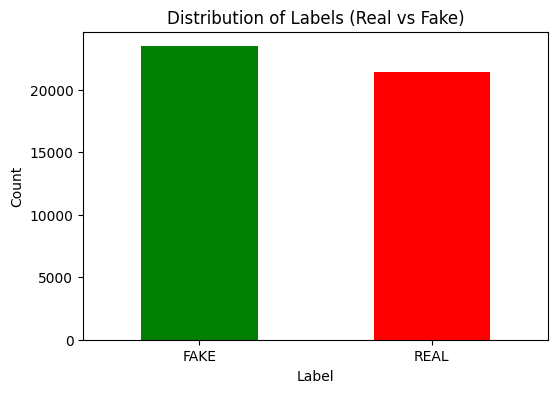

In [28]:
import matplotlib.pyplot as plt

# Plot the distribution of labels
label_counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Labels (Real vs Fake)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [29]:
df['full_input_length'] = df['full_input'].apply(len)
df['summary_length'] = df['summary'].apply(len)

plt.figure(figsize=(8, 6))
plt.scatter(df['full_input_length'], df['summary_length'], alpha=0.5, color='blue')
plt.title('Full Text Length vs. Summary Length')
plt.xlabel('Full Input Length')
plt.ylabel('Summary Length')
plt.show()


KeyError: 'summary'

In [30]:
import pandas as pd

# Create data
data = {
    "Feature": ["Output Style", "Dependency on context", "Quality for fake news"],
    "Extractive": ["Sentence snippets", "Limited", "Sometimes misleading"],
    "Abstractive": ["Rephrased human-like summary", "High", "More accurate representation"]
}

# Create DataFrame
df = pd.DataFrame(data)

# Set Feature as index for better layout
df.set_index("Feature", inplace=True)

# Display
from IPython.display import display, HTML
display(HTML(df.to_html(classes='table table-striped', border=0)))


,Extractive,Abstractive
Feature,,
Output Style,Sentence snippets,Rephrased human-like summary
Dependency on context,Limited,High
Quality for fake news,Sometimes misleading,More accurate representation
